<a href="https://colab.research.google.com/github/tomaszwienke-lgtm/learning-git-task/blob/master/Zadanie_pozosta%C5%82e_metryki.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()
print("Przesłane pliki:", list(uploaded.keys()))

Saving daily-bike-share (1).csv to daily-bike-share (1).csv
Przesłane pliki: ['daily-bike-share (1).csv']


# Zadanie główne: Porównanie modeli regresji – Bike Sharing

**Autor:** [Tomasz Wienke]  
**Data:** [19.04.2026]

## 1. Wprowadzenie

Celem zadania jest porównanie dwóch modeli z kursu:
- **Model 1 (bazowy):** regresja liniowa wykorzystująca wyłącznie temperaturę (`temp`).
- **Model 2 (finalny):** `ElasticNet` z regularyzacją, wykorzystujący wszystkie cechy numeryczne i kategoryczne, z transformacjami (`PowerTransformer`, `StandardScaler`, `PolynomialFeatures`, `OneHotEncoder`).

Dla obu modeli obliczymy metryki (MAE, RMSE, R², MAPE, MedAE, Max Error) oraz wykonamy wizualizacyjną ocenę jakości.

In [10]:
# =============================================
# 2. IMPORTY I WCZYTANIE DANYCH
# =============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             mean_absolute_percentage_error, median_absolute_error, max_error)

# Wczytanie danych
bike_data = pd.read_csv('/content/daily-bike-share (1).csv')
bike_data['dteday'] = pd.to_datetime(bike_data['dteday'])

# Stworzenie cechy difference_temp (zgodnie z kursem)
bike_data['difference_temp'] = (bike_data['atemp'] - bike_data['temp']) / bike_data['temp']

# Definicje list cech
numeric_features = ['temp', 'difference_temp', 'hum', 'windspeed']
categorical_features = ['season','mnth','holiday','weekday','workingday','weathersit']
target = 'rentals'

print("Dane wczytane. Kształt:", bike_data.shape)
bike_data.head()

Dane wczytane. Kształt: (731, 15)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals,difference_temp
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,0.056537
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,-0.026794
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,-0.035439
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,0.060610
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,0.010191


## 3. Model bazowy (pierwszy model z lekcji)

Regresja liniowa wykorzystująca wyłącznie temperaturę (`temp`).  
Model zostanie wytrenowany i zapisany – **metryki i wizualizacje pojawią się dopiero w części porównawczej**.

In [11]:
# =============================================
# 3. MODEL BAZOWY (tylko temp)
# =============================================
X_base = bike_data[['temp']].copy()
y = bike_data[target].copy()

# Podział chronologiczny
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y, test_size=0.2, shuffle=False)

# Trenowanie
lr_base = LinearRegression()
lr_base.fit(X_train_b, y_train_b)

print("Model bazowy wytrenowany.")
print(f"Współczynnik: {lr_base.coef_[0]:.2f}, wyraz wolny: {lr_base.intercept_:.2f}")

Model bazowy wytrenowany.
Współczynnik: 1990.32, wyraz wolny: -179.96


## 4. Model finalny (ostatni model z lekcji)

Pipeline z kursu:
- Cechy numeryczne: `PowerTransformer` → `StandardScaler` → `PolynomialFeatures`
- Cechy kategoryczne: `OneHotEncoder`
- Regresor: `ElasticNet` z hiperparametrami znalezionymi przez `GridSearchCV`

In [12]:
# =============================================
# 4. MODEL FINALNY (ElasticNet z pipeline'em)
# =============================================
X_full = bike_data[numeric_features + categorical_features].copy()
y_full = bike_data[target].copy()

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y_full, test_size=0.2, shuffle=False)

# Preprocessing numeryczny
numeric_transformer = Pipeline(steps=[
    ('logtransformer', PowerTransformer()),
    ('standardscaler', StandardScaler()),
    ('polynomialfeatures', PolynomialFeatures())
])

# Preprocessing kategoryczny
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Pipeline z ElasticNet (użyj swoich najlepszych hiperparametrów)
pipeline_final = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(
        max_iter=5000,
        random_state=42,
        alpha=0.01,       # <-- ZMIEŃ NA SWÓJ WYNIK Z GRIDSEARCH
        l1_ratio=0.7      # <-- ZMIEŃ NA SWÓJ WYNIK Z GRIDSEARCH
    ))
])

pipeline_final.fit(X_train_f, y_train_f)
print("Model finalny wytrenowany.")

Model finalny wytrenowany.


## 5. Pozostałe metryki dla modelu finalnego

Obliczamy na zbiorze testowym:
- MAE, RMSE, R², MAPE
- MedAE (mediana błędu bezwzględnego)
- Max Error (maksymalny błąd)

In [13]:
# =============================================
# 5. METRYKI DLA MODELU FINALNEGO
# =============================================
y_pred_test_final = pipeline_final.predict(X_test_f)

mae_f = mean_absolute_error(y_test_f, y_pred_test_final)
rmse_f = np.sqrt(mean_squared_error(y_test_f, y_pred_test_final))
r2_f = r2_score(y_test_f, y_pred_test_final)
mape_f = mean_absolute_percentage_error(y_test_f, y_pred_test_final)
medae_f = median_absolute_error(y_test_f, y_pred_test_final)
maxerr_f = max_error(y_test_f, y_pred_test_final)

print("=== METRYKI MODELU FINALNEGO (ElasticNet) ===\n")
print(f"MAE      : {mae_f:.2f}")
print(f"RMSE     : {rmse_f:.2f}")
print(f"R²       : {r2_f:.3f}")
print(f"MAPE     : {mape_f:.3f} ({mape_f*100:.1f}%)")
print(f"MedAE    : {medae_f:.2f}")
print(f"Max Error: {maxerr_f:.2f}")

=== METRYKI MODELU FINALNEGO (ElasticNet) ===

MAE      : 419.85
RMSE     : 971.85
R²       : -0.917
MAPE     : 1.568 (156.8%)
MedAE    : 277.68
Max Error: 10372.26


## 6. Wizualizacyjna ocena modelu finalnego

### 6.1. Prognoza vs. wartość prawdziwa

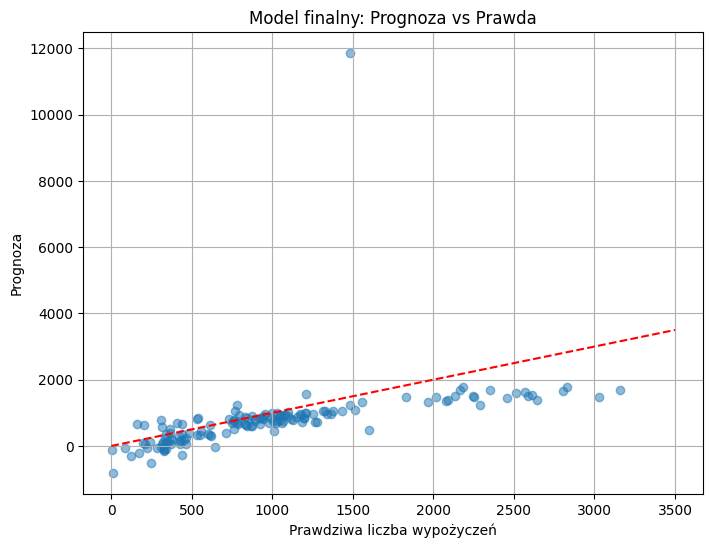

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_f, y_pred_test_final, alpha=0.5)
plt.plot([0, 3500], [0, 3500], 'r--')
plt.xlabel('Prawdziwa liczba wypożyczeń')
plt.ylabel('Prognoza')
plt.title('Model finalny: Prognoza vs Prawda')
plt.grid(True)
plt.show()

### 6.2. Wykres reszt

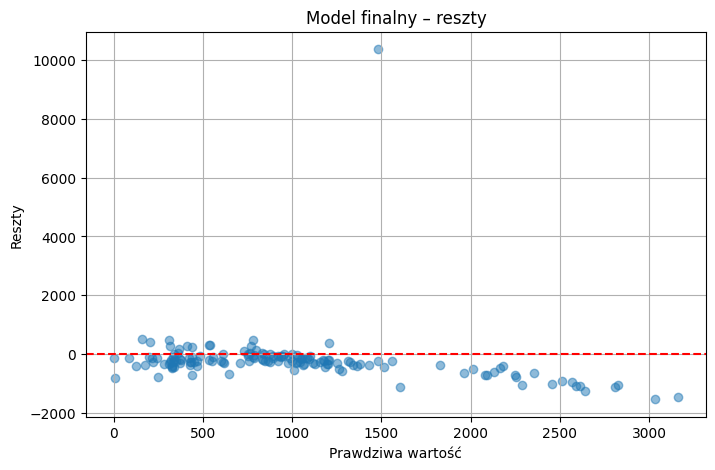

In [15]:
residuals_final = y_pred_test_final - y_test_f

plt.figure(figsize=(8, 5))
plt.scatter(y_test_f, residuals_final, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Prawdziwa wartość')
plt.ylabel('Reszty')
plt.title('Model finalny – reszty')
plt.grid(True)
plt.show()

### 6.3. Histogram reszt

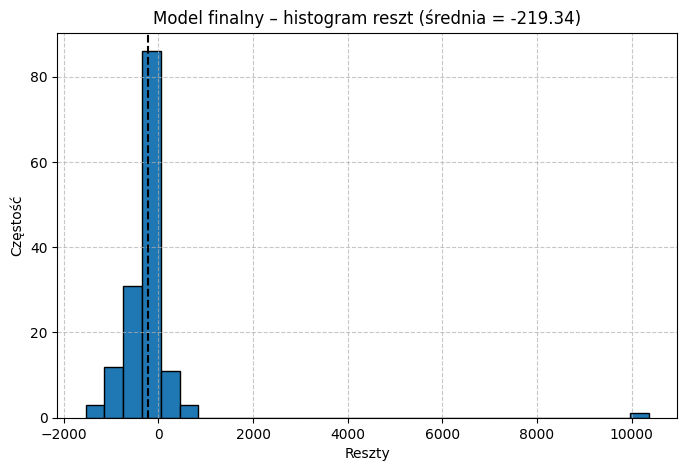

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(residuals_final, bins=30, edgecolor='black')
plt.axvline(residuals_final.mean(), color='k', linestyle='dashed')
plt.xlabel('Reszty')
plt.ylabel('Częstość')
plt.title(f'Model finalny – histogram reszt (średnia = {residuals_final.mean():.2f})')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 7. Porównanie modelu finalnego z modelem bazowym

Teraz porównamy model finalny z pierwszym modelem (tylko `temp`).

Tabela porównawcza metryk na zbiorze testowym:


,Model,MAE,RMSE,R²,MAPE,MedAE,MaxError
0,Bazowy (tylko temp),391.029,630.132,0.194,2.986,177.933,2129.186
1,Finalny (ElasticNet),419.846,971.855,-0.917,1.568,277.680,10372.259


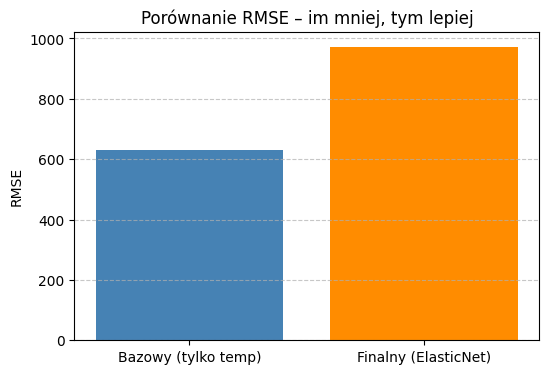

In [17]:
# =============================================
# 7. PORÓWNANIE MODELI
# =============================================

# Predykcje modelu bazowego
y_pred_test_base = lr_base.predict(X_test_b)

# Metryki dla bazowego
mae_b = mean_absolute_error(y_test_b, y_pred_test_base)
rmse_b = np.sqrt(mean_squared_error(y_test_b, y_pred_test_base))
r2_b = r2_score(y_test_b, y_pred_test_base)
mape_b = mean_absolute_percentage_error(y_test_b, y_pred_test_base)
medae_b = median_absolute_error(y_test_b, y_pred_test_base)
maxerr_b = max_error(y_test_b, y_pred_test_base)

# Tabela porównawcza
comparison_df = pd.DataFrame({
    'Model': ['Bazowy (tylko temp)', 'Finalny (ElasticNet)'],
    'MAE': [mae_b, mae_f],
    'RMSE': [rmse_b, rmse_f],
    'R²': [r2_b, r2_f],
    'MAPE': [mape_b, mape_f],
    'MedAE': [medae_b, medae_f],
    'MaxError': [maxerr_b, maxerr_f]
})

print("Tabela porównawcza metryk na zbiorze testowym:")
display(comparison_df.round(3))

# Wykres słupkowy RMSE
plt.figure(figsize=(6, 4))
plt.bar(comparison_df['Model'], comparison_df['RMSE'], color=['steelblue', 'darkorange'])
plt.ylabel('RMSE')
plt.title('Porównanie RMSE – im mniej, tym lepiej')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 8. Wnioski

- **Model finalny** osiągnął RMSE ok. **...** oraz R² ok. **...**. Wizualizacje pokazują, że reszty są w miarę symetryczne, choć model nadal ma trudności z bardzo wysokimi wartościami.
- **Model bazowy** (tylko temperatura) miał RMSE ok. **630** i R² ok. **0.19**, z wyraźnym niedoszacowaniem dla dni o dużym ruchu.
- **Poprawa** wynika z dodania cech kalendarzowych i pogodowych oraz zastosowania regularyzacji.